# EEG NCDF Quality Report Demo

This notebook demonstrates quality checking for one exported EEG NetCDF file using MNE + AutoReject.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

from src.export import run_eeg_autoreject_quality_report

In [2]:
# Point this to your exported UNIWAW folder (the same one used in export notebooks).
export_folder = Path("/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported")

# Find candidate EEG NCDF files and pick one.
candidates = sorted([p for p in export_folder.rglob("*.nc") if "_EEG_" in p.name])

if not candidates:
    raise FileNotFoundError(
        f"No EEG NetCDF files found under: {export_folder}. Export at least one dyad first."
    )

ncdf_path = candidates[0]
print(f"Using file: {ncdf_path}")

Using file: /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/EEG/W_000/caregiver/W_000_EEG_cg_Brave.nc


Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 40 events and 256 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/21 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/21 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/40 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/40 [00:00<?,       ?it/s]

  0%|          | Fold : 0/5 [00:00<?,       ?it/s]





Estimated consensus=0.50 and n_interpolate=2


  0%|          | Repairing epochs : 0/40 [00:00<?,       ?it/s]

Dropped 2 epochs: 2, 14


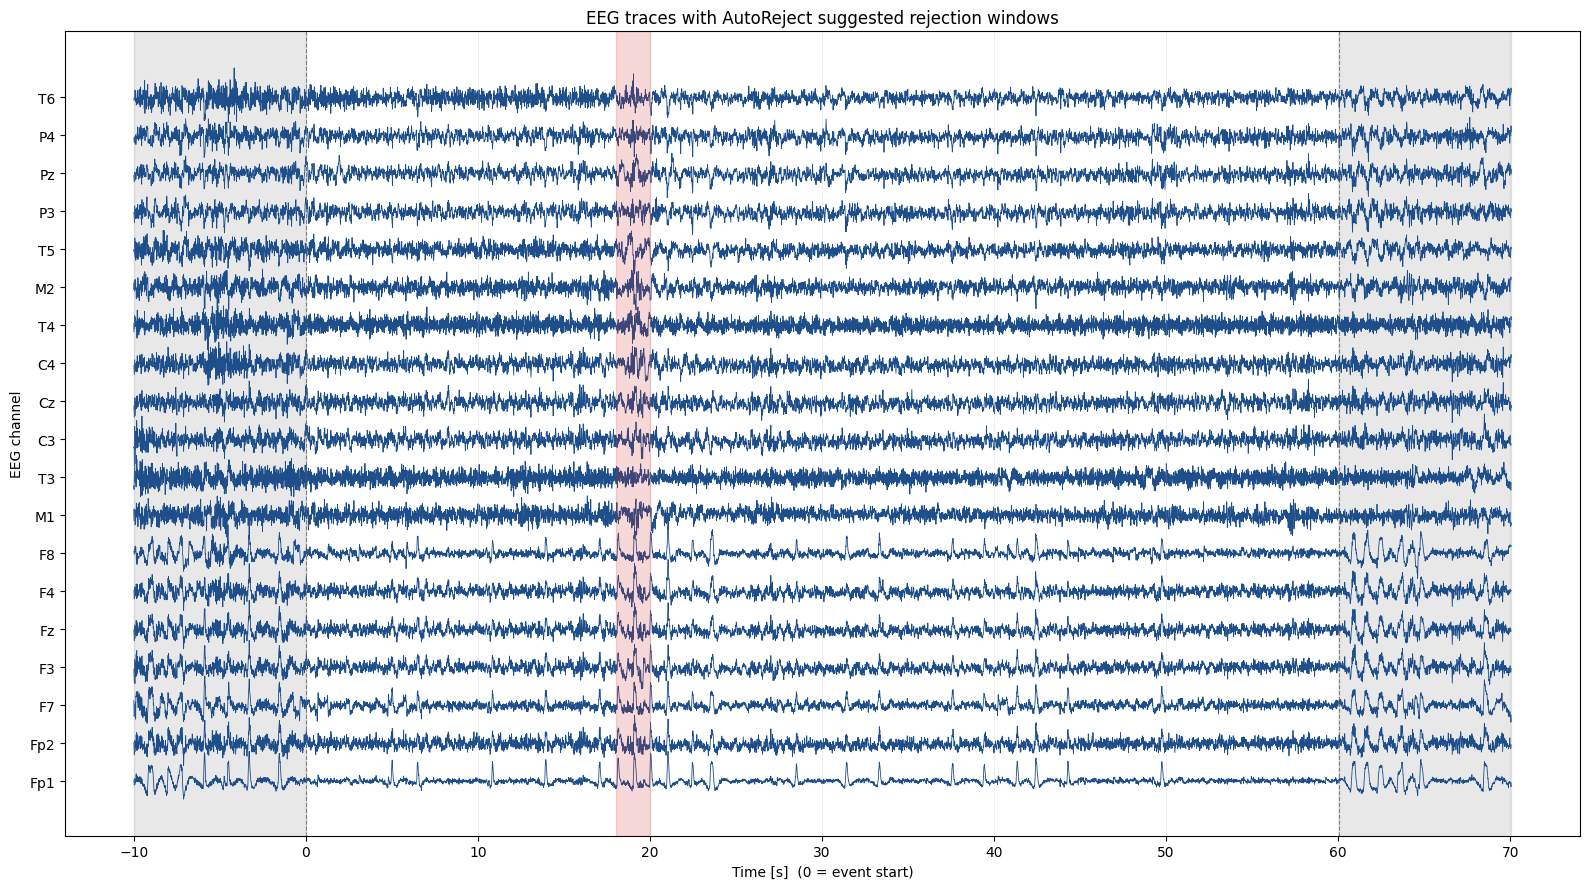

In [3]:
report = run_eeg_autoreject_quality_report(
    ncdf_path=str(ncdf_path),
    epoch_duration_s=2.0,
    n_interpolate=(1, 2, 4),
    cv=5,
    random_state=42,
    n_jobs=-1,
    montage="standard_1020",
    scale_to_volts=1e-6,
    verbose=True,
)

## How to interpret this AutoReject report

- The signal shown in the plot is the original EEG from NCDF (after unit scaling and display normalization), not a permanently corrected signal.
- Red shaded windows are epochs that AutoReject suggests to reject (`rejected=True`).
- `interpolated_channels` means how many channels would be repaired in a given 2s epoch.
- In channel summary:
  - `interpolated_epochs` = in how many epochs channel needed interpolation.
  - `bad_labels` = in how many epochs channel was strongly problematic.
- Practical reading:
  - low `rejected_epochs_pct` and low `interpolated_pct` -> generally good quality,
  - high values concentrated in a few channels -> likely electrode/channel-specific issue,
  - high values across many channels -> global artifact / poor recording period.

In [4]:
global_summary_dict = dict(report["global_summary"])
global_summary_dict["ncdf_file"] = Path(str(ncdf_path)).name
global_summary_dict.pop("ncdf_path", None)

global_summary = pd.Series(global_summary_dict, name="value")
epoch_summary = report["epoch_summary"]
channel_summary = report["channel_summary"]

print("Global summary:")
display(global_summary.to_frame())

print("Top channels by bad labels/interpolations:")
display(channel_summary.head(10))

print("Channel quality interpretation:")
for _, row in channel_summary.head(10).iterrows():
    problematic_pct = float(row["interpolated_pct"]) + float(row["bad_labels_pct"])
    fixable_pct = float(row["interpolated_pct"])
    still_bad_pct = float(row["bad_labels_pct"])
    print(
        f"- {row['channel']} was problematic in {problematic_pct:.1f}% of epochs: "
        f"{fixable_pct:.1f}% fixable + {still_bad_pct:.1f}% still bad"
    )

print("First epochs summary rows:")
display(epoch_summary.head(10))

Global summary:


,value
n_channels,21
n_epochs,40
epoch_duration_s,2.0
rejected_epochs,2
rejected_epochs_pct,5.0
total_interpolations,89
ncdf_file,W_000_EEG_cg_Brave.nc


Top channels by bad labels/interpolations:


,channel,interpolated_epochs,bad_labels,interpolated_pct,bad_labels_pct
0,Fp1,0,26,0.0,65.0
1,T3,18,21,45.0,52.5
2,F8,3,15,7.5,37.5
3,F7,4,3,10.0,7.5
4,F4,12,1,30.0,2.5
5,O1,7,1,17.5,2.5
6,T4,3,1,7.5,2.5
7,Fp2,11,0,27.5,0.0
8,Fz,11,0,27.5,0.0
9,F3,5,0,12.5,0.0


Channel quality interpretation:
- Fp1 was problematic in 65.0% of epochs: 0.0% fixable + 65.0% still bad
- T3 was problematic in 97.5% of epochs: 45.0% fixable + 52.5% still bad
- F8 was problematic in 45.0% of epochs: 7.5% fixable + 37.5% still bad
- F7 was problematic in 17.5% of epochs: 10.0% fixable + 7.5% still bad
- F4 was problematic in 32.5% of epochs: 30.0% fixable + 2.5% still bad
- O1 was problematic in 20.0% of epochs: 17.5% fixable + 2.5% still bad
- T4 was problematic in 10.0% of epochs: 7.5% fixable + 2.5% still bad
- Fp2 was problematic in 27.5% of epochs: 27.5% fixable + 0.0% still bad
- Fz was problematic in 27.5% of epochs: 27.5% fixable + 0.0% still bad
- F3 was problematic in 12.5% of epochs: 12.5% fixable + 0.0% still bad
First epochs summary rows:


,epoch_idx,start_s,end_s,interpolated_channels,rejected,in_margin
0,0,-10.0,-8.0,6,False,True
1,1,-8.0,-6.0,7,False,True
2,2,-6.0,-4.0,10,True,True
3,3,-4.0,-2.0,7,False,True
4,4,-2.0,0.0,6,False,True
5,5,0.0,2.0,0,False,False
6,6,2.0,4.0,0,False,False
7,7,4.0,6.0,1,False,False
8,8,6.0,8.0,3,False,False
9,9,8.0,10.0,0,False,False


In [5]:
# Save a single TOML-like quality summary CSV + the PNG visualization.
# File names are based on the analyzed NCDF base name for traceability.
out_dir = ncdf_path.parent
base_name = ncdf_path.stem

report_csv = out_dir / f"{base_name}_quality_report.csv"
plot_png = out_dir / f"{base_name}_quality_plot.png"

channel_summary = report["channel_summary"].copy()
epoch_summary = report["epoch_summary"].copy()
global_summary = dict(report["global_summary"])

# Keep only file name (no full folder path) in the report payload.
global_summary["ncdf_file"] = Path(str(ncdf_path)).name
global_summary.pop("ncdf_path", None)
# Drop redundant count fields.
global_summary.pop("n_channels", None)
global_summary.pop("n_epochs", None)

def _toml_scalar(value):
    if isinstance(value, bool):
        return "true" if value else "false"
    if isinstance(value, (int, float)):
        return str(value)
    if value is None:
        return '""'
    text = str(value).replace('"', '\\"')
    return f'"{text}"'

rows = []

# 1. ncdf_file at the very top.
rows.append({"section": "global", "key": "ncdf_file", "value": _toml_scalar(global_summary["ncdf_file"])})

# 2. rejected_epoch_count + rejected windows (margin epochs excluded) immediately below filename.
# Epochs within the pre/post-event margins are expected to be noisy and are not reported.
rejected_epochs = epoch_summary.loc[epoch_summary["rejected"] & ~epoch_summary["in_margin"]]
rows.append({
    "section": "global",
    "key": "rejected_epochs",
    "value": str(int(len(rejected_epochs))),
})
for _, row in rejected_epochs.iterrows():
    rows.append({
        "section": "rejected_windows",
        "key": f"epoch_{int(row['epoch_idx'])}",
        "value": (
            f"{{start_s={float(row['start_s']):.3f}, "
            f"end_s={float(row['end_s']):.3f}, "
            f"interpolated_channels={int(row['interpolated_channels'])}}}"
        ),
    })

# 3. Remaining global fields (skip already-written ones).
skip_keys = {"ncdf_file", "n_channels", "n_epochs"}
for key, value in global_summary.items():
    if key not in skip_keys:
        rows.append({"section": "global", "key": key, "value": _toml_scalar(value)})

# 4. Top channels (percentages only, rounded to full percent).
top_channels = channel_summary.head(10)
for idx, row in top_channels.iterrows():
    problematic_pct = int(round(float(row["interpolated_pct"]) + float(row["bad_labels_pct"])))
    fixable_pct = int(round(float(row["interpolated_pct"])))
    still_bad_pct = int(round(float(row["bad_labels_pct"])))
    rows.append({
        "section": "top_channels",
        "key": f"ch_{idx + 1}",
        "value": (
            f"{{name={_toml_scalar(row['channel'])}, "
            f"problematic_pct={problematic_pct}, "
            f"fixable_pct={fixable_pct}, "
            f"still_bad_pct={still_bad_pct}}}"
        ),
    })

pd.DataFrame(rows).to_csv(report_csv, index=False)
report["figure"].savefig(plot_png, dpi=200, bbox_inches="tight")

print("Saved quality artifacts:")
print(f"- {report_csv}")
print(f"- {plot_png}")

Saved quality artifacts:
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/EEG/W_000/caregiver/W_000_EEG_cg_Brave_quality_report.csv
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/EEG/W_000/caregiver/W_000_EEG_cg_Brave_quality_plot.png


In [6]:
# Plot from report already includes highlighted rejection windows.
fig = report["figure"]
plt.show()